# MUSIC PROGRAM

   age  gender   genre
0   20       1  HipHop
1   23       1  HipHop
2   25       1  HipHop
3   26       1    Jazz
4   29       1    Jazz
Dataset Shape:
(18, 3)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     18 non-null     int64
 1   gender  18 non-null     int64
 2   genre   18 non-null     str  
dtypes: int64(2), str(1)
memory usage: 564.0 bytes
None

Summary Statistics
             age     gender
count  18.000000  18.000000
mean   27.944444   0.500000
std     5.127460   0.514496
min    20.000000   0.000000
25%    25.000000   0.000000
50%    28.000000   0.500000
75%    31.000000   1.000000
max    37.000000   1.000000

Data Types
age       int64
gender    int64
genre       str
dtype: object


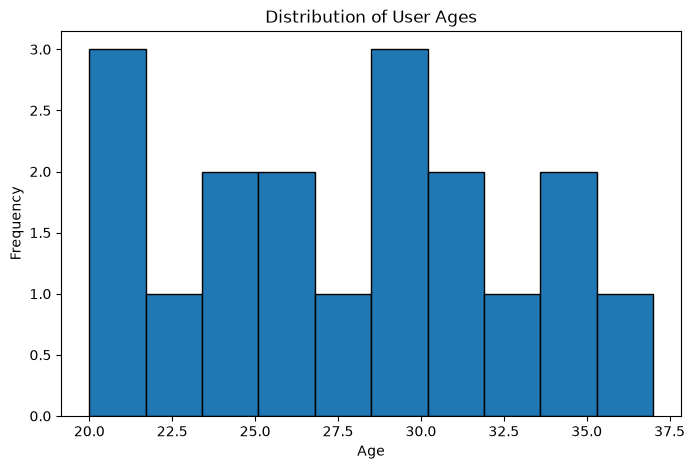


Missing Values
age       0
gender    0
genre     0
dtype: int64

Duplicate Rows: 0

Outliers:

Training Records: 14

Testing Records: 4
['HipHop' 'HipHop' 'Classical' 'Jazz']
Music Preference for User 1 is: HipHop
Music Preference for User 2 is: HipHop
Accuracy: 1.0


In [3]:
#DATA ENTRY AND DESCRIPTION
#Data Manuplation
import pandas as pd
import numpy as np
#Data Visualisation
import matplotlib.pyplot as plt
# Machine Learning
from sklearn.model_selection import train_test_split #Splitting the Dataset
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.metrics import accuracy_score, classification_report #Evaluate well machine learning performance after making predications
#Load Data
music_data= pd.read_csv(r"C:\Users\KARTICS CONSULTS\Desktop\music.csv")
# Display first five rows
print(music_data.head())
#Exploring Data
#Check Data Shape
print ("Dataset Shape:")
print(music_data.shape)
#Dispaly Dataset Information
print("\nDataset Information")
print(music_data.info())
#Descriptive Statistics
print("\nSummary Statistics")
print(music_data.describe())

#Data Types
print("\nData Types")
print(music_data.dtypes)
#Visualisation of Age Distribution
plt.figure(figsize=(8,5))
plt.hist(music_data['age'], bins=10, edgecolor='black')
plt.title("Distribution of User Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Checking for missing Values
print("\nMissing Values")
print(music_data.isnull().sum())

#Checking for Duplicate Records
print("\nDuplicate Rows:", music_data.duplicated().sum())
#Detecting Outliers
Q1 = music_data['age'].quantile(0.25)
Q3 = music_data['age'].quantile(0.75)
IQR = Q3 - Q1
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR
outliers = music_data[(music_data['age'] < Lower) | (music_data['age'] > Upper)]
print("\nOutliers:")

#MODELING DATA
#Seperating Features (Age, Gender) and Targets (Genre)
X = music_data[['age','gender']]
y = music_data['genre']
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42
)
print("\nTraining Records:", X_train.shape[0])
print("\nTesting Records:", X_test.shape[0])
#Creating Decision Tree Classifier Model
model = DecisionTreeClassifier(random_state=42)
#Training the Model
model.fit(X_train, y_train)
#Making Predictions on Test Set
predictions = model.predict(X_test)
print(predictions)

##Predict Music Preference for New Users
#New User1. 21 year old male; note... male coded 1 and female 0
new_user1 = pd.DataFrame([[21, 1]], columns=['age', 'gender'])
prediction = model.predict(new_user1)
print("Music Preference for User 1 is:", prediction[0])
#New User 2. 30 year old female
new_user2 = pd.DataFrame([[30,0]], columns=['age','gender'])
print("Music Preference for User 2 is:", prediction[0])

##Evaluating the model
#Accuracy Score
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)
#Classification Report
report = classification_report(y_test, predictions)
